In [44]:
import numpy as np
import pandas as pd

import yfinance as yf
from datetime import date
from scipy.signal import savgol_filter

import matplotlib.pyplot as plt

In [98]:
today = date.today()

start = '2025-01-01'
end = today.strftime("%Y-%m-%d")

SYMBOL = "SPY"

In [99]:
#data = yf.download(SYMBOL, start, end)
data = yf.download(tickers=SYMBOL, period="1d", interval="5m")
data.reset_index(inplace=True, drop=False)
data = data.droplevel(1, axis=1)

[*********************100%***********************]  1 of 1 completed


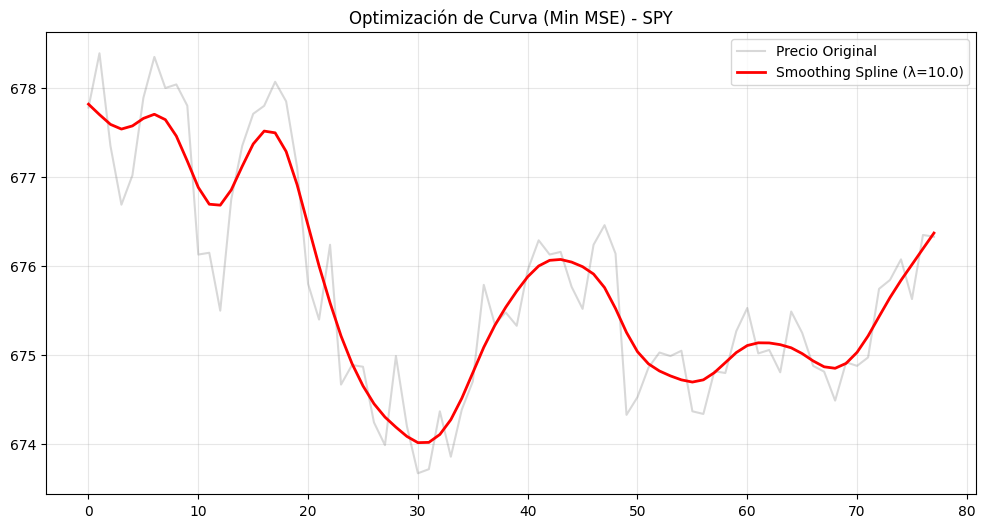

In [100]:
from scipy.interpolate import make_smoothing_spline

# 1. Preparar datos
# Usamos un índice numérico para la optimización
x = np.arange(len(data))
y = data['Close'].values

# 2. Aplicar el Smoothing Spline
# 'lam' es el parámetro de suavizado (λ). 
# Un lam más alto = más suave (polinómico), lam más bajo = más ajustado al ruido.
# Prueba valores entre 0.1 y 10.0 según tu necesidad de suavidad.
lam = 10.0 
spline_func = make_smoothing_spline(x, y, lam=lam)

# 3. Generar la curva suave
data['Spline_SM'] = spline_func(x)

# --- Gráfico de alta precisión ---
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Precio Original', color='gray', alpha=0.3)
plt.plot(data.index, data['Spline_SM'], label=f'Smoothing Spline (λ={lam})', color='red', linewidth=2)

plt.title(f'Optimización de Curva (Min MSE) - {SYMBOL}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [101]:
f_prime.derivative

<bound method BSpline.derivative of <scipy.interpolate._bsplines.BSpline object at 0x306c55f00>>

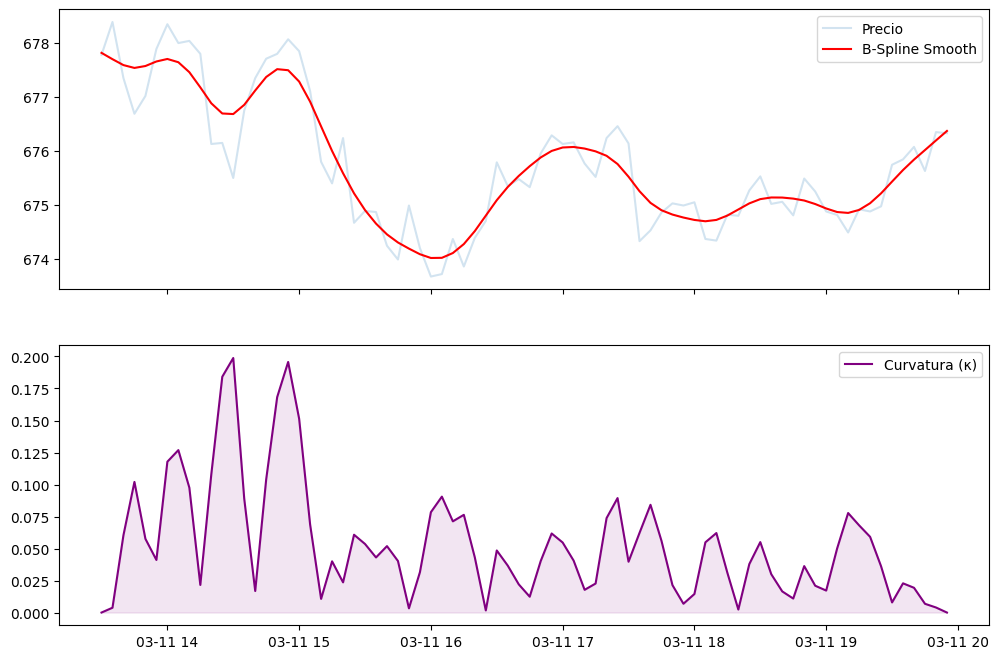

In [102]:
f_prime = spline_func.derivative()
f_double_prime = f_prime.derivative()

# 2. Calculamos los valores sobre nuestro índice x
data['Velocidad'] = f_prime(x)
data['Aceleracion'] = f_double_prime(x)

# 3. Cálculo de la Curvatura Matemática (Kappa)
data['Curvatura'] = np.abs(data['Aceleracion']) / (1 + data['Velocidad']**2)**1.5

# --- Visualización ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Gráfico superior: Precio y Spline
ax1.plot(data['Datetime'], data['Close'], alpha=0.2, label='Precio')
ax1.plot(data['Datetime'], data['Spline_SM'], color='red', label='B-Spline Smooth')
ax1.legend()

# Gráfico inferior: Curvatura
# La curvatura nos dice qué tan "cerrada" es la vuelta que está dando el precio
ax2.plot(data['Datetime'], data['Curvatura'], color='purple', label='Curvatura (κ)')
ax2.fill_between(data['Datetime'], 0, data['Curvatura'], color='purple', alpha=0.1)
ax2.legend()

plt.show()

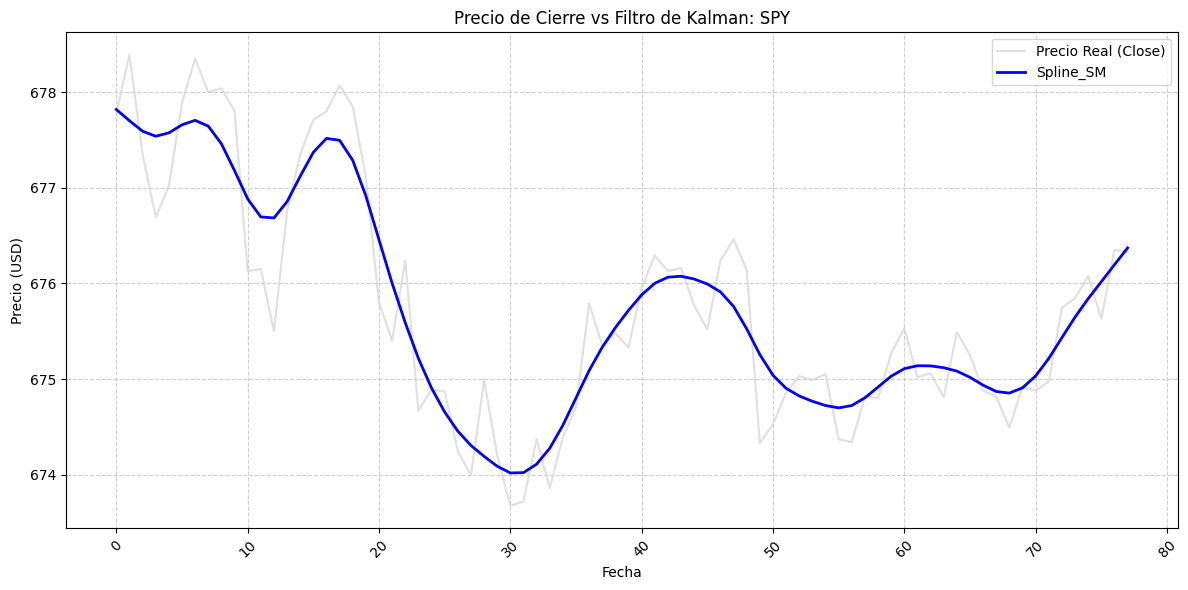

In [103]:
# Configuramos el tamaño y el título
plt.figure(figsize=(12, 6))
plt.title(f'Precio de Cierre vs Filtro de Kalman: {SYMBOL}')

# 1. Ploteamos el precio real (un poco más tenue para resaltar el filtro)
plt.plot(data.index, data['Close'], label='Precio Real (Close)', color='lightgray', alpha=0.7)

# 2. Ploteamos el Filtro de Kalman
plt.plot(data.index, data['Spline_SM'], label='Spline_SM', color='blue', linewidth=2)

# Formateo de ejes y estética
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Rotamos las fechas para que no se amontonen
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

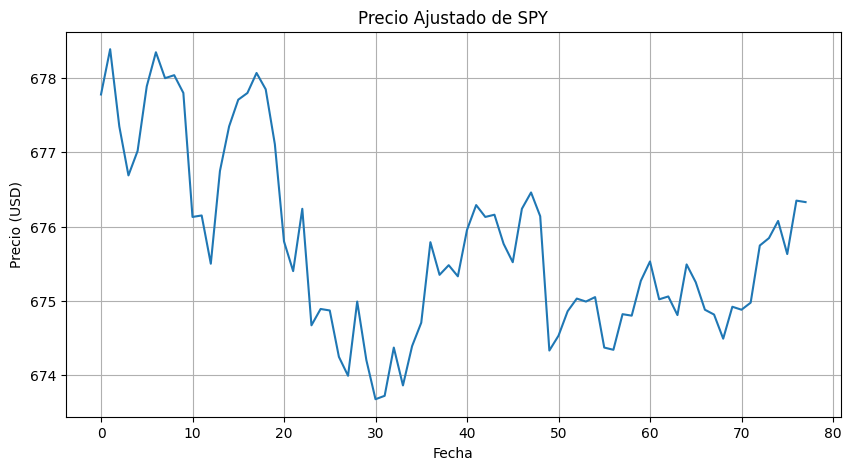

In [104]:
data['Close'].plot(figsize=(10, 5), title=f'Precio Ajustado de {SYMBOL}')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.grid()
plt.show()

In [105]:
data['daily_return'] = data['Close'].pct_change()

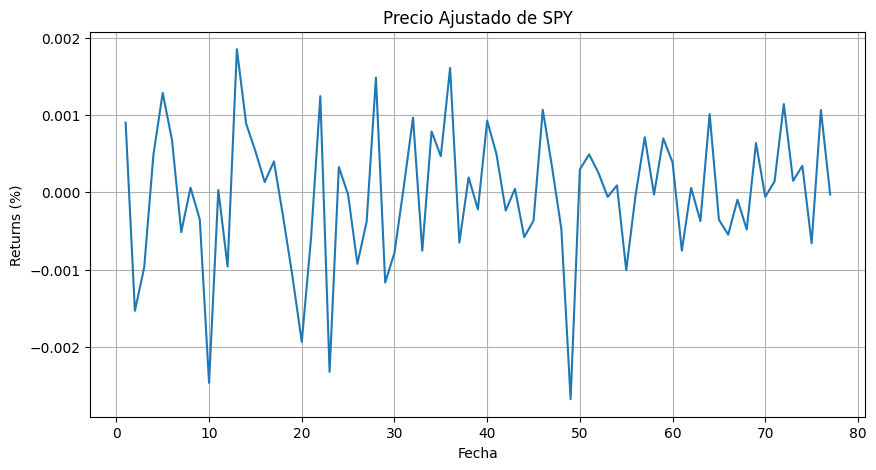

In [106]:
data['daily_return'].plot(figsize=(10, 5), title=f'Precio Ajustado de {SYMBOL}')
plt.xlabel('Fecha')
plt.ylabel('Returns (%)')
plt.grid()
plt.show()

In [107]:
SYMBOL2 = '^VIX'

#vol_imp = yf.download(SYMBOL2, start, end)
vol_imp = yf.download(tickers=SYMBOL2, period="1d", interval="5m")
vol_imp.reset_index(inplace=True, drop=False)
vol_imp = vol_imp.droplevel(1, axis=1)

[*********************100%***********************]  1 of 1 completed


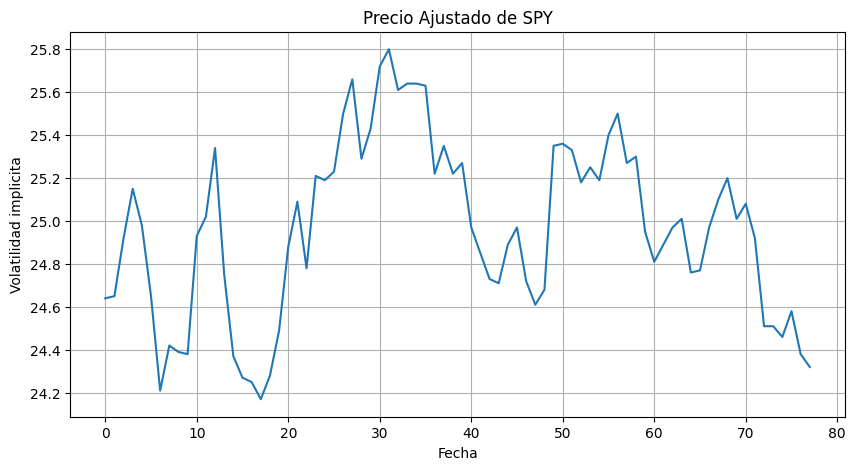

In [108]:
vol_imp['Close'].plot(figsize=(10, 5), title=f'Precio Ajustado de {SYMBOL}')
plt.xlabel('Fecha')
plt.ylabel('Volatilidad implicita')
plt.grid()
plt.show()

In [109]:
data['direction'] = np.sign(data['Close'].diff())
data['OBV'] = (data['direction'] * data['Volume']).fillna(0).cumsum()
print(data[['Close', 'Volume', 'OBV']].tail())

Price       Close   Volume        OBV
73     675.844971   890341  2680429.0
74     676.076111   570974  3251403.0
75     675.630005   909719  2341684.0
76     676.349976  1723027  4064711.0
77     676.330017  2815703  1249008.0


In [110]:
# Parámetros
period = 14

# 1. Precio Típico
typical_price = (data['High'] + data['Low'] + data['Close']) / 3
money_flow = typical_price * data['Volume']

# 2. Diferencia para saber si el flujo es positivo o negativo
price_diff = typical_price.diff()

pos_flow = pd.Series(np.where(price_diff > 0, money_flow, 0), index=data.index)
neg_flow = pd.Series(np.where(price_diff < 0, money_flow, 0), index=data.index)

# 3. Calcular el Money Ratio
m_ratio = pos_flow.rolling(window=period).sum() / neg_flow.rolling(window=period).sum()

# 4. Calcular el MFI (Fórmula estándar)
data['MFI'] = 100 - (100 / (1 + m_ratio))

print(data)

Price                  Datetime       Close        High         Low  \
0     2026-03-11 13:30:00+00:00  677.780029  678.380005  677.520020   
1     2026-03-11 13:35:00+00:00  678.390015  678.440002  677.609985   
2     2026-03-11 13:40:00+00:00  677.349976  678.500000  677.169983   
3     2026-03-11 13:45:00+00:00  676.690002  677.919983  676.419983   
4     2026-03-11 13:50:00+00:00  677.020020  677.649475  676.130005   
..                          ...         ...         ...         ...   
73    2026-03-11 19:35:00+00:00  675.844971  676.000000  675.469971   
74    2026-03-11 19:40:00+00:00  676.076111  676.250000  675.690002   
75    2026-03-11 19:45:00+00:00  675.630005  676.229980  675.500000   
76    2026-03-11 19:50:00+00:00  676.349976  676.390015  675.409973   
77    2026-03-11 19:55:00+00:00  676.330017  676.599976  676.140015   

Price        Open   Volume   Spline_SM  Velocidad   Aceleracion     Curvatura  \
0      677.580017  3562491  677.818515  -0.116641 -3.410605e-13  3

In [111]:
yf.download(SYMBOL, period="1d")

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2026-03-11,676.330017,680.080017,673.340027,677.580017,67291756


In [112]:
data['mf_multiplier'] = ((data['Close'] - data['Low']) - (data['High'] - data['Close'])) / (data['High'] - data['Low'])

# Si el High y Low son iguales (raro), el multiplicador sería NaN, lo corregimos:
data['mf_multiplier'] = data['mf_multiplier'].fillna(0)

# 3. Calcular el Money Flow Volume (MFV)
data['mf_volume'] = data['mf_multiplier'] * data['Volume']

# 4. Calcular el CMF (estándar de 20 periodos)
# Es la suma del Money Flow Volume de 20 días dividida por la suma del Volumen de 20 días
periodo = 20
data['CMF'] = data['mf_volume'].rolling(window=periodo).sum() / data['Volume'].rolling(window=periodo).sum()

print(data[['Close', 'CMF']].tail())

Price       Close       CMF
73     675.844971  0.167885
74     676.076111  0.172103
75     675.630005  0.150264
76     676.349976  0.208044
77     676.330017  0.135235


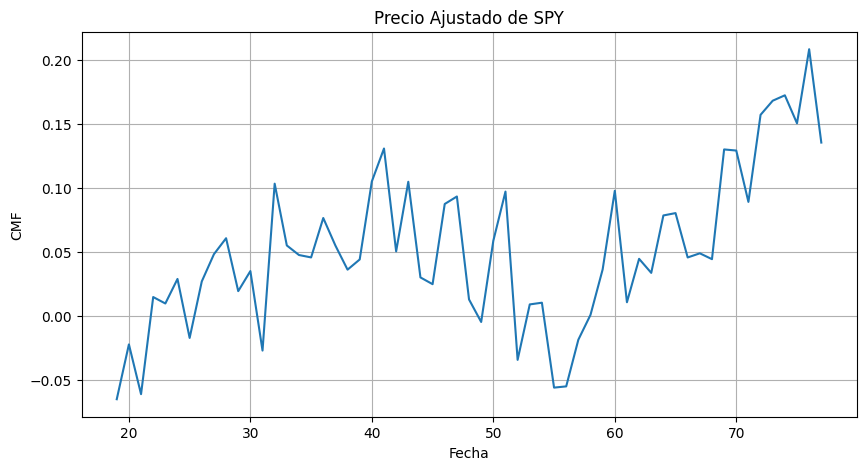

In [113]:
data['CMF'].plot(figsize=(10, 5), title=f'Precio Ajustado de {SYMBOL}')
plt.xlabel('Fecha')
plt.ylabel('CMF')
plt.grid()
plt.show()

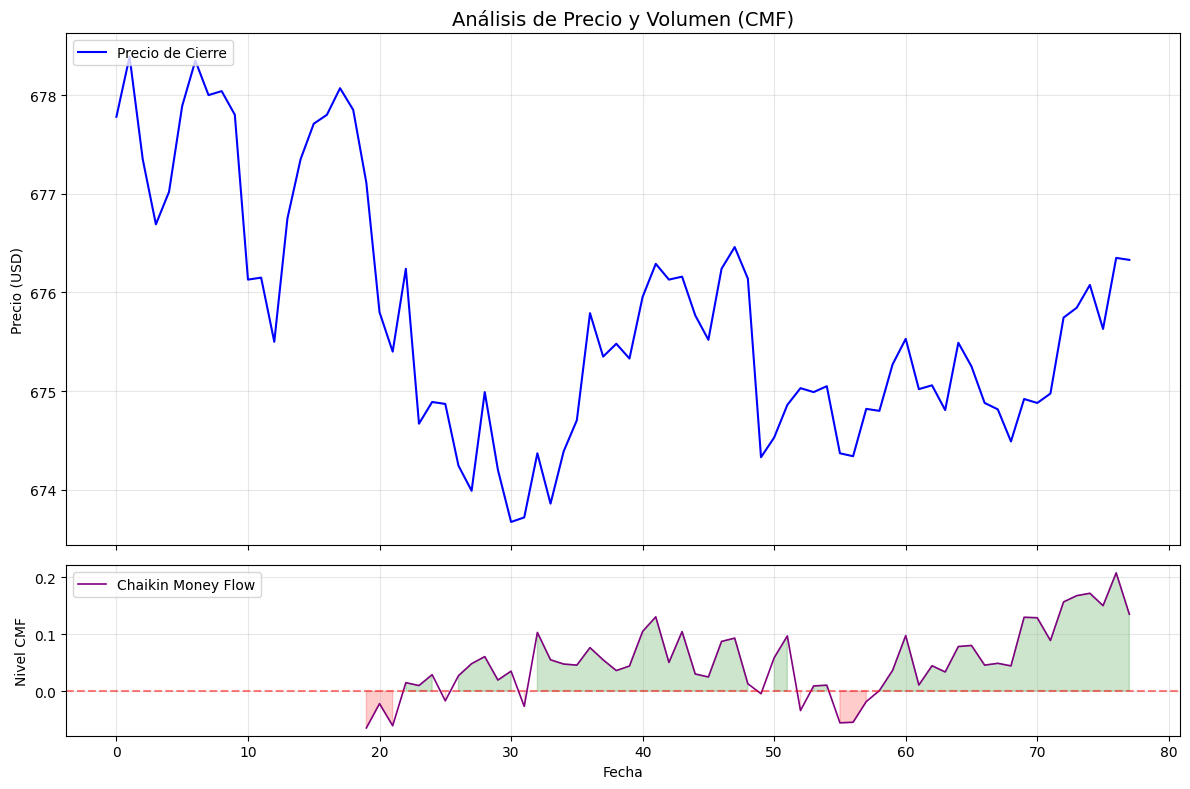

In [114]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(data.index, data['Close'], label='Precio de Cierre', color='blue', lw=1.5)
ax1.set_title('Análisis de Precio y Volumen (CMF)', fontsize=14)
ax1.set_ylabel('Precio (USD)')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

ax2.plot(data.index, data['CMF'], label='Chaikin Money Flow', color='purple', lw=1.2)
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)  # Línea de equilibrio en 0
ax2.set_ylabel('Nivel CMF')
ax2.set_xlabel('Fecha')

ax2.fill_between(data.index, data['CMF'], 0, where=(data['CMF'] >= 0), color='green', alpha=0.2)
ax2.fill_between(data.index, data['CMF'], 0, where=(data['CMF'] < 0), color='red', alpha=0.2)

ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

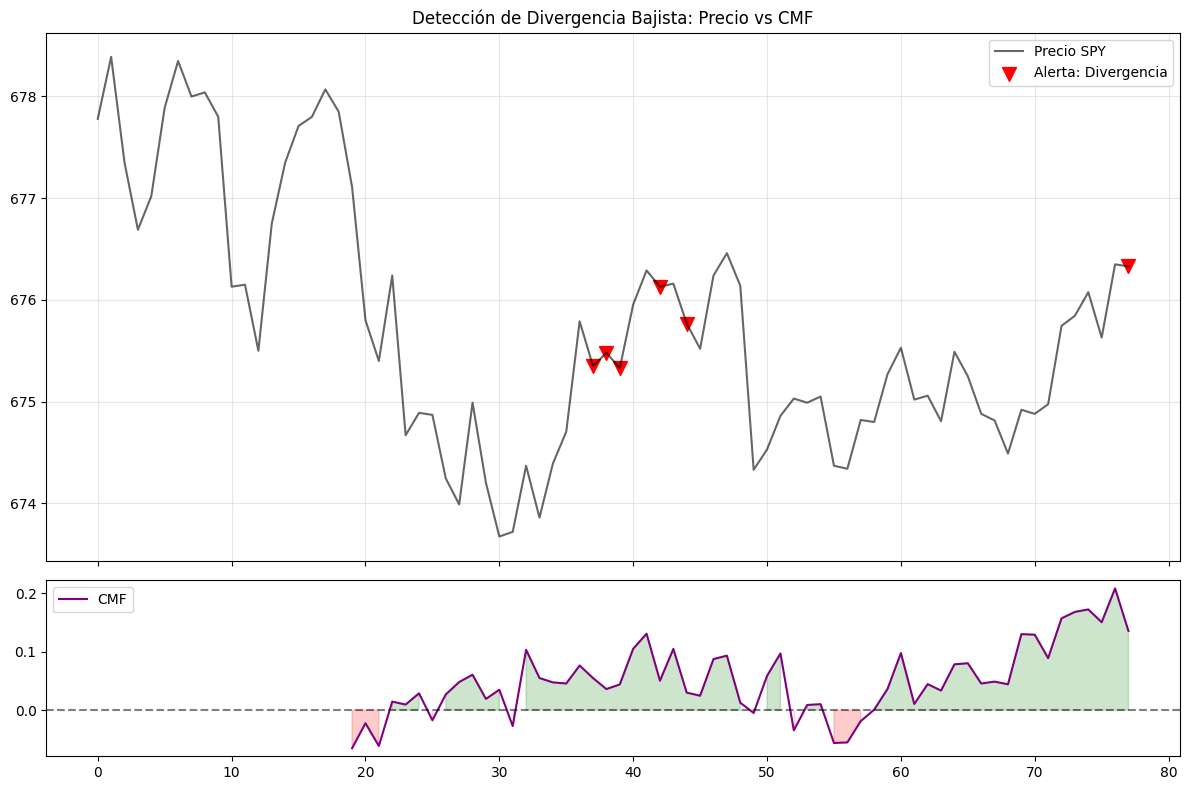

In [115]:
# 3. Lógica de Detección de Divergencia
# Comparamos el estado actual vs hace 5 días (puedes ajustar esta ventana)
n = 5 

# Condición A: El precio está más alto que hace n días
price_rising = data['Close'] > data['Close'].shift(n)

# Condición B: El flujo de dinero (CMF) está más bajo que hace n días
cmf_falling = data['CMF'] < data['CMF'].shift(n)

# Condición C: El CMF aún es positivo (la divergencia es más potente en la cima)
cmf_positive = data['CMF'] > 0

# Creamos la columna de señal (True/False)
data['bearish_divergence'] = price_rising & cmf_falling & cmf_positive

# 4. Visualización Profesional
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Gráfico de Precio
ax1.plot(data.index, data['Close'], color='black', alpha=0.6, label='Precio SPY')
# Dibujar flechas rojas donde hay divergencia
signals = data[data['bearish_divergence']]
ax1.scatter(signals.index, signals['Close'], color='red', marker='v', s=100, label='Alerta: Divergencia')

ax1.set_title('Detección de Divergencia Bajista: Precio vs CMF')
ax1.legend()
ax1.grid(alpha=0.3)

# Gráfico de CMF
ax2.plot(data.index, data['CMF'], color='purple', label='CMF')
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.fill_between(data.index, data['CMF'], 0, where=(data['CMF'] >= 0), color='green', alpha=0.2)
ax2.fill_between(data.index, data['CMF'], 0, where=(data['CMF'] < 0), color='red', alpha=0.2)
ax2.legend()

plt.tight_layout()
plt.show()